# How to add a trainable readout

**Task.** Decode a continuous output from a spiking network with a
`LeakyRateReadout` head, and train it end to end.

**Audience.** Training. Assumes :doc:`../tutorials/04-train-an-snn`.

A spiking hidden layer emits 0/1 events; to produce a smooth, trainable output
you read it out through a leaky rate unit. `brainpy.state.LeakyRateReadout`
applies a trainable weight and low-pass filters the result with time constant
`tau`, giving a differentiable `[batch, out]` signal you can attach a loss to.

In [1]:
import brainpy
import brainstate
import braintools
import brainunit as u
import matplotlib.pyplot as plt
import numpy as np

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## A recurrent SNN with a rate readout

The hidden layer is a surrogate-gradient LIF; the readout maps its spikes to the
output classes.

In [2]:
class ReadoutSNN(brainstate.nn.Module):
    def __init__(self, n_in, n_rec, n_out):
        super().__init__()
        self.i2r = brainstate.nn.Sequential(
            brainstate.nn.Linear(
                n_in, n_rec,
                w_init=braintools.init.KaimingNormal(unit=u.mA),
                b_init=braintools.init.ZeroInit(unit=u.mA)),
            brainpy.state.Expon(n_rec, tau=5. * u.ms,
                                g_initializer=braintools.init.Constant(0. * u.mA)))
        self.r = brainpy.state.LIF(
            n_rec, tau=20. * u.ms, V_rest=0. * u.mV, V_reset=0. * u.mV,
            V_th=1. * u.mV, spk_fun=braintools.surrogate.ReluGrad())
        # trainable, low-pass readout head
        self.readout = brainpy.state.LeakyRateReadout(n_rec, n_out, tau=10. * u.ms)

    def update(self, spike):
        return self.readout(self.r(self.i2r(spike)))

## Train it

The loss averages the readout over time and applies a cross-entropy, exactly as
before; only the output head has changed.

In [3]:
with brainstate.environ.context(dt=1.0 * u.ms):
    n_in, n_rec, n_out = 100, 8, 3
    num_step, num_sample = 150, 128
    net = ReadoutSNN(n_in, n_rec, n_out)

    x_data = (brainstate.random.rand(num_step, num_sample, n_in)
              < 6. * u.Hz * brainstate.environ.get_dt()).astype(float)
    y_data = u.math.asarray(brainstate.random.randint(0, n_out, (num_sample,)), dtype=int)

    optimizer = braintools.optim.Adam(lr=2e-3)
    optimizer.register_trainable_weights(net.states(brainstate.ParamState))

    def loss_fn():
        preds = brainstate.transform.for_loop(net.update, x_data)   # [T, B, C]
        preds = u.math.mean(preds, axis=0)
        return braintools.metric.softmax_cross_entropy_with_integer_labels(
            preds, y_data).mean()

    @brainstate.transform.jit
    def train_step():
        brainstate.nn.init_all_states(net, batch_size=num_sample)
        grads, l = brainstate.transform.grad(
            loss_fn, net.states(brainstate.ParamState), return_value=True)()
        optimizer.update(grads)
        return l

    losses = [float(train_step()) for _ in range(200)]

print('first %.4f  last %.4f' % (losses[0], losses[-1]))

first 1.0986  last 0.8690


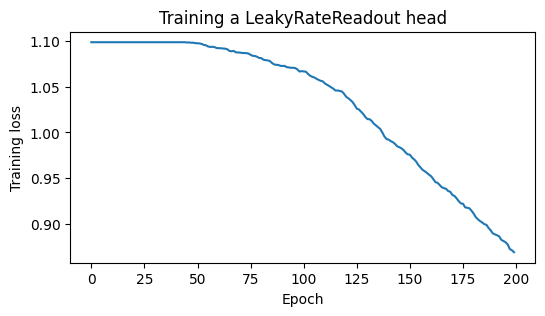

In [4]:
plt.figure(figsize=(6, 3))
plt.plot(np.asarray(losses))
plt.xlabel('Epoch'); plt.ylabel('Training loss')
plt.title('Training a LeakyRateReadout head')
plt.show()

## See also

- :doc:`/apis/brainpy-readouts` — `LeakyRateReadout` reference.
- :doc:`train-surrogate-gradients` — the surrogate on the hidden layer.
- :doc:`train-long-rollouts-checkpoint` — long-sequence training.